# 04 - SHAP Explainability (Fixed)

This notebook explains the tuned Logistic Regression stroke-classification model using SHAP.

**Important fixes:**
- Does not depend on an incompatible previously pickled scikit-learn model.
- Recreates the exact train/test split used in `03_model_training.ipynb`.
- Rebuilds the tuned Logistic Regression model using the same GridSearchCV settings.
- Uses `shap.LinearExplainer` on the scaler-transformed data, which is appropriate for Logistic Regression.
- Keeps the original feature names/values for readable SHAP plots.
- Explains the positive class (`stroke = 1`).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

print('SHAP version:', shap.__version__)


SHAP version: 0.52.0


## 1. Load data and recreate the same train/test split

In [2]:
df = pd.read_csv('../dataset/processed/cleaned_stroke_dataset.csv')

X = df.drop('stroke', axis=1)
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('Training data:', X_train.shape)
print('Testing data :', X_test.shape)
print('Feature count:', X_train.shape[1])
print('\nTraining target distribution:')
print(y_train.value_counts())


Training data: (4088, 21)
Testing data : (1022, 21)
Feature count: 21

Training target distribution:
stroke
0    3889
1     199
Name: count, dtype: int64


## 2. Rebuild the tuned Logistic Regression model

The original training notebook found these best settings:

`C=0.1`, `class_weight='balanced'`, `solver='lbfgs'`.

Rebuilding the model here avoids the scikit-learn pickle-version problem that occurred when loading `stroke_model.pkl`.

In [3]:
logistic_model = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ))
])

param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__class_weight': ['balanced', None],
    'classifier__solver': ['liblinear', 'lbfgs']
}

grid_search = GridSearchCV(
    logistic_model,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_logistic_model = grid_search.best_estimator_

print('Best parameters:')
print(grid_search.best_params_)
print('\nBest CV ROC-AUC:', grid_search.best_score_)


Best parameters:
{'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__solver': 'lbfgs'}

Best CV ROC-AUC: 0.8375837683356965


## 3. Verify the model

This is only a sanity check. The SHAP analysis below explains the same tuned model.

In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_pred = best_logistic_model.predict(X_test)
y_prob = best_logistic_model.predict_proba(X_test)[:, 1]

print('Tuned Logistic Regression Results')
print('----------------------------------')
print('Accuracy :', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred, zero_division=0))
print('Recall   :', recall_score(y_test, y_pred, zero_division=0))
print('F1 Score :', f1_score(y_test, y_pred, zero_division=0))
print('ROC-AUC  :', roc_auc_score(y_test, y_prob))


Tuned Logistic Regression Results
----------------------------------
Accuracy : 0.7455968688845401
Precision: 0.13793103448275862
Recall   : 0.8
F1 Score : 0.23529411764705882
ROC-AUC  : 0.8431069958847737


## 4. Prepare the Logistic Regression model for SHAP

The model is a Pipeline containing `StandardScaler` followed by `LogisticRegression`.

SHAP's `LinearExplainer` is applied to the actual Logistic Regression estimator after transforming the features with the same fitted scaler. This avoids treating the whole pipeline as a black box.

In [5]:
scaler = best_logistic_model.named_steps['scaler']
classifier = best_logistic_model.named_steps['classifier']

# Apply exactly the same fitted scaler used by the pipeline.
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Explain a manageable sample of the test set.
sample_size = min(200, len(X_test))
rng = np.random.default_rng(42)
explain_idx = rng.choice(len(X_test), size=sample_size, replace=False)

X_explain = X_test.iloc[explain_idx].copy()
X_explain_scaled = scaler.transform(X_explain)

explainer = shap.LinearExplainer(classifier, X_train_scaled)
raw_shap_values = explainer(X_explain_scaled)

print('SHAP values shape:', raw_shap_values.values.shape)
print('Expected feature count:', X_explain.shape[1])


Background dataset has 4088 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=4088 when initializing the masker.


SHAP values shape: (200, 21)
Expected feature count: 21


### Why the SHAP values are built this way

`LinearExplainer` explains the Logistic Regression model's linear output (log-odds). Positive SHAP values push a prediction toward `stroke = 1`; negative SHAP values push it toward `stroke = 0`.

The original, unscaled feature values are attached to the SHAP object only for readability in the plots.

In [6]:
shap_values = shap.Explanation(
    values=raw_shap_values.values,
    base_values=raw_shap_values.base_values,
    data=X_explain.to_numpy(),
    feature_names=X_explain.columns.tolist()
)

print('Ready for SHAP plots.')


Ready for SHAP plots.


## 5. Global feature importance

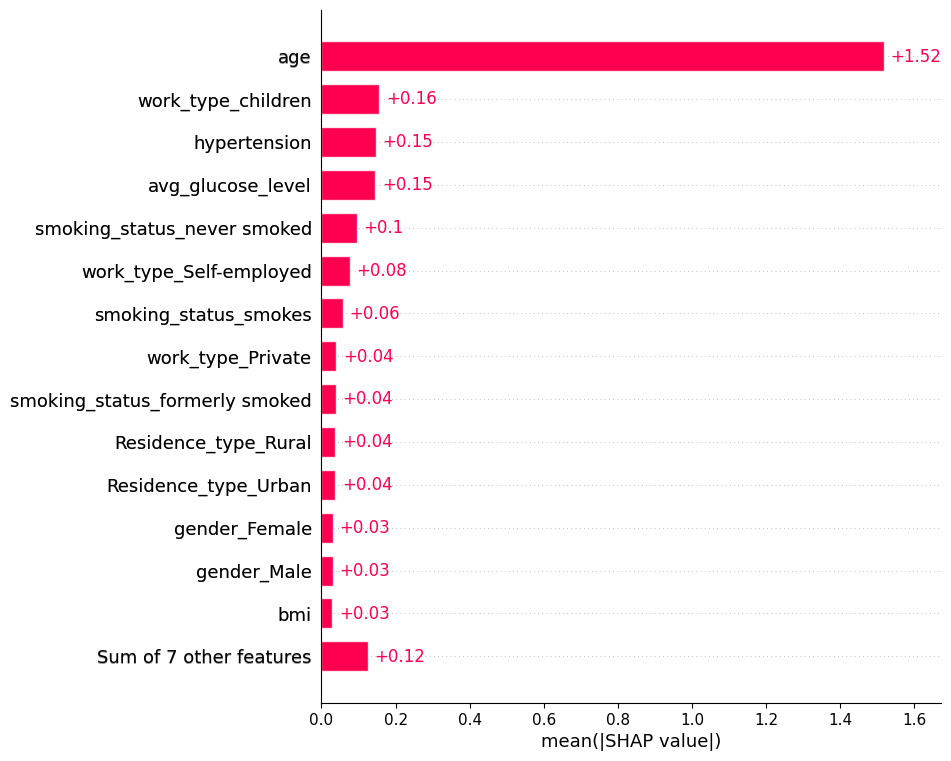

In [7]:
shap.plots.bar(shap_values, max_display=15)


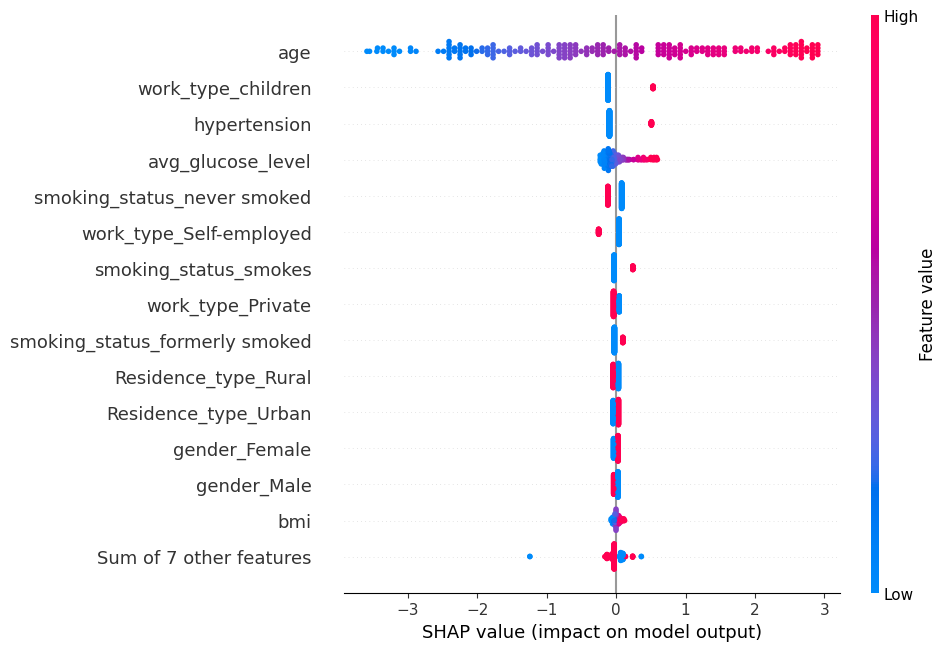

In [8]:
shap.plots.beeswarm(shap_values, max_display=15)


## 6. Identify the most influential feature

The ranking below is based on mean absolute SHAP value.

In [9]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
importance_df = pd.DataFrame({
    'Feature': X_explain.columns,
    'Mean_Absolute_SHAP': mean_abs_shap
}).sort_values('Mean_Absolute_SHAP', ascending=False)

print(importance_df.head(15).to_string(index=False))

top_feature = importance_df.iloc[0]['Feature']
print('\nTop feature:', top_feature)


                       Feature  Mean_Absolute_SHAP
                           age            1.517333
            work_type_children            0.156029
                  hypertension            0.145959
             avg_glucose_level            0.145625
   smoking_status_never smoked            0.096063
       work_type_Self-employed            0.076930
         smoking_status_smokes            0.057032
             work_type_Private            0.040147
smoking_status_formerly smoked            0.038420
          Residence_type_Rural            0.037465
          Residence_type_Urban            0.037465
                 gender_Female            0.031104
                   gender_Male            0.030060
                           bmi            0.029203
               ever_married_No            0.027200

Top feature: age


## 7. SHAP dependence/scatter plot for the top feature

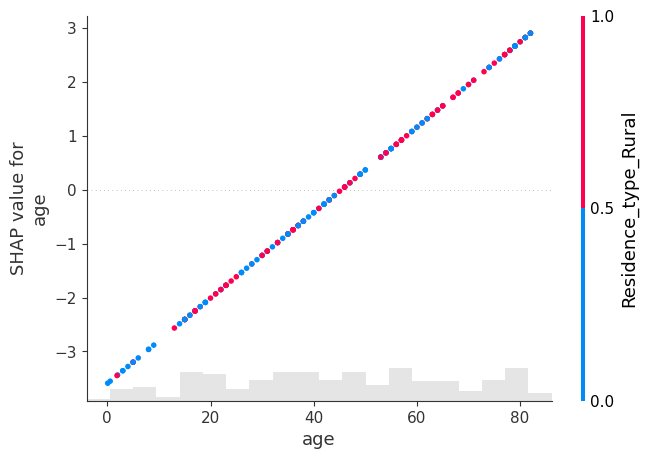

In [10]:
top_feature_index = X_explain.columns.get_loc(top_feature)
shap.plots.scatter(shap_values[:, top_feature_index], color=shap_values)


## 8. Local explanation for one patient

This waterfall plot shows how the individual feature values move the selected patient's prediction away from the baseline toward higher or lower stroke risk according to the model.

Predicted class: 0
Predicted stroke probability: 0.15838204958746097


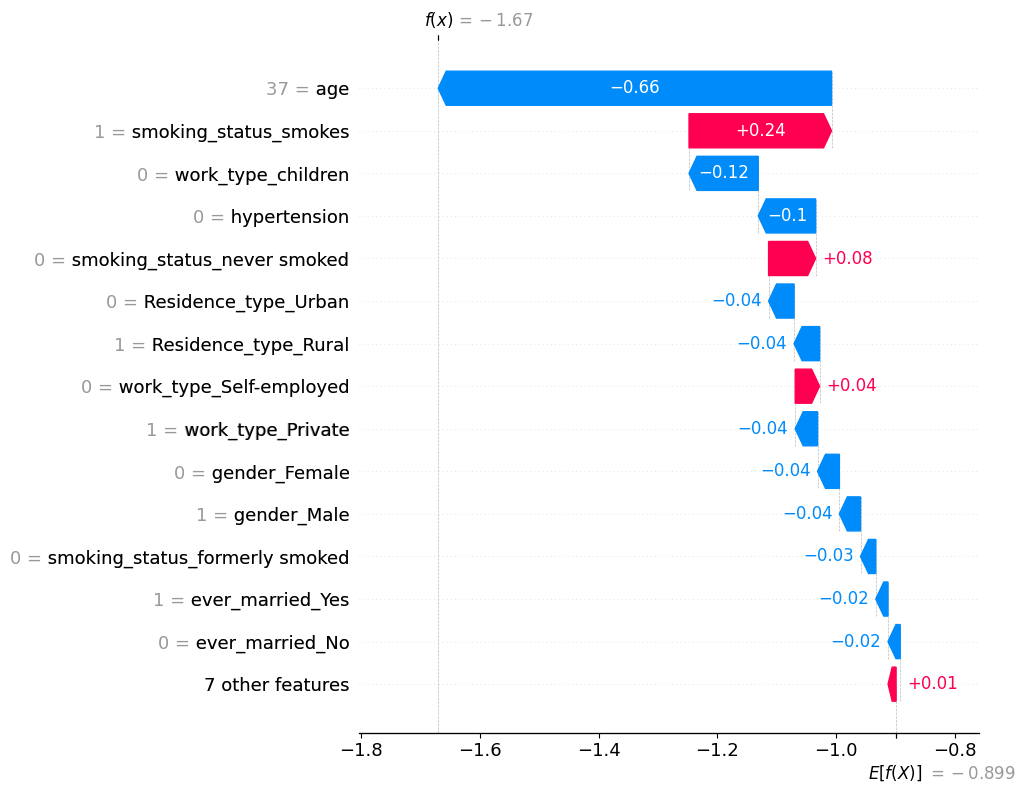

In [11]:
idx = 0

print('Predicted class:', best_logistic_model.predict(X_explain.iloc[[idx]])[0])
print('Predicted stroke probability:', best_logistic_model.predict_proba(X_explain.iloc[[idx]])[0, 1])

shap.plots.waterfall(shap_values[idx], max_display=15)


## 9. Save SHAP results

In [12]:
os.makedirs('../models', exist_ok=True)

np.save('../models/shap_values_logistic.npy', shap_values.values)
X_explain.to_csv('../models/shap_explained_rows.csv', index=False)
importance_df.to_csv('../models/shap_feature_importance.csv', index=False)

print('SHAP values, explained rows, and feature importance saved successfully.')


SHAP values, explained rows, and feature importance saved successfully.
